<a href="https://colab.research.google.com/github/zinebidrissijanati1-debug/ERF-REPO/blob/main/ERF_number_of_iterations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== Iterations: 10 ===
Selected Features: [ 1  4  5  7  9 11 12 15 16 18 21 23 24 25 26]
Accuracy: 0.9701
Time: 119.46 seconds
Confusion Matrix:
[[201  11]
 [  6 351]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       212
           1       0.97      0.98      0.98       357

    accuracy                           0.97       569
   macro avg       0.97      0.97      0.97       569
weighted avg       0.97      0.97      0.97       569


=== Iterations: 20 ===
Selected Features: [ 1  2  3  4  7  9 11 14 17 19 20 21 23 26 28 29]
Accuracy: 0.9736
Time: 241.03 seconds
Confusion Matrix:
[[202  10]
 [  5 352]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       212
           1       0.97      0.99      0.98       357

    accuracy                           0.97       569
   macro avg       0.97      0.97      0.97       569
weighted avg  

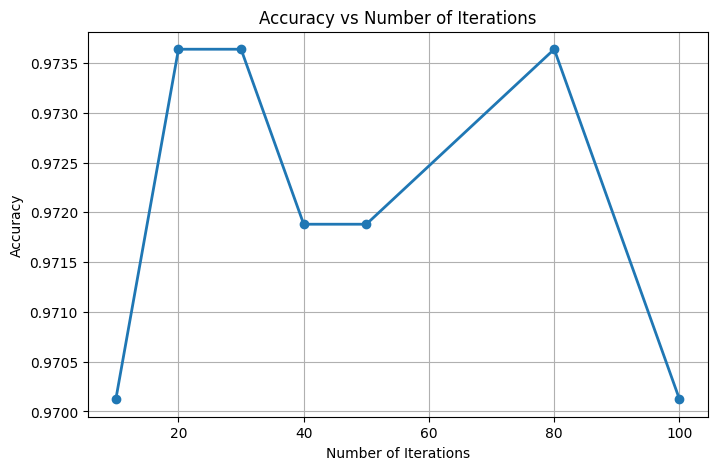

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target
n_features = X.shape[1]

# Parameters
iteration_values = [10, 20, 30, 40, 50, 80, 100]
pop_size = 20
mutation_rate = 0.2
n_estimators = 50
max_depth = None
criterion = 'gini'
bootstrap = True
random_state = 0

# Store results
results = {}

# Genetic algorithm components
def initial_population(size, length):
    return [np.random.randint(2, size=length) for _ in range(size)]

def decode_chromosome(chromosome):
    return np.where(chromosome == 1)[0]

def selection(pop, scores):
    next_gen = []
    total_score = sum(scores)
    probs = [s / total_score for s in scores]
    for _ in range(len(pop)):
        idx = np.random.choice(len(pop), p=probs)
        next_gen.append(pop[idx])
    return next_gen

def crossover(pop):
    children = []
    for i in range(0, len(pop), 2):
        if i + 1 < len(pop):
            parent1, parent2 = pop[i], pop[i+1]
            point = len(parent1) // 2
            child1 = np.concatenate((parent1[:point], parent2[point:]))
            child2 = np.concatenate((parent2[:point], parent1[point:]))
            children.extend([child1, child2])
        else:
            children.append(pop[i])
    return children

def mutation(pop, rate):
    mutated = []
    for individual in pop:
        if np.random.rand() < rate:
            idx = np.random.randint(len(individual))
            individual[idx] = 1 - individual[idx]
        mutated.append(individual)
    return mutated

def cross_val_fitness(chromosome):
    selected = decode_chromosome(chromosome)
    if len(selected) == 0:
        return 0.0
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    scores = []
    for train_idx, test_idx in kf.split(X):
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            criterion=criterion,
            bootstrap=bootstrap,
            random_state=random_state
        )
        model.fit(X[train_idx][:, selected], y[train_idx])
        preds = model.predict(X[test_idx][:, selected])
        scores.append(accuracy_score(y[test_idx], preds))
    return np.mean(scores)

# Main loop
for iteration in iteration_values:
    start_time = time.time()
    population = initial_population(pop_size, n_features)
    best_individual = None
    best_score = 0

    for gen in range(iteration):
        scores = [cross_val_fitness(ind) for ind in population]
        max_idx = np.argmax(scores)
        if scores[max_idx] > best_score:
            best_score = scores[max_idx]
            best_individual = population[max_idx]

        population = selection(population, scores)
        population = crossover(population)
        population = mutation(population, mutation_rate)

    # Final evaluation on full dataset
    selected_features = decode_chromosome(best_individual)
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        criterion=criterion,
        bootstrap=bootstrap,
        random_state=random_state
    )
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    all_preds, all_true = [], []

    for train_idx, test_idx in kf.split(X):
        model.fit(X[train_idx][:, selected_features], y[train_idx])
        preds = model.predict(X[test_idx][:, selected_features])
        all_preds.extend(preds)
        all_true.extend(y[test_idx])

    end_time = time.time()
    cm = confusion_matrix(all_true, all_preds)
    report = classification_report(all_true, all_preds, output_dict=True)
    duration = end_time - start_time

    results[iteration] = {
        "accuracy": accuracy_score(all_true, all_preds),
        "confusion_matrix": cm,
        "report": report,
        "time": duration
    }

    # Print results
    print(f"\n=== Iterations: {iteration} ===")
    print(f"Selected Features: {selected_features}")
    print(f"Accuracy: {results[iteration]['accuracy']:.4f}")
    print(f"Time: {duration:.2f} seconds")
    print("Confusion Matrix:")
    print(cm)
    print("Classification Report:")
    print(classification_report(all_true, all_preds))

# Plot accuracy vs iterations
plt.figure(figsize=(8, 5))
plt.plot(iteration_values, [results[i]['accuracy'] for i in iteration_values], marker='o', linewidth=2)
plt.title('Accuracy vs Number of Iterations')
plt.xlabel('Number of Iterations')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()
